# 06 Open-ended Exploration: Model Comparison + Domain Feature Engineering

This notebook extends Phases 4 and 5 with two of the PDF's suggested open-ended techniques:

1. **Model Comparison (≥3 classes, cross-validated):** Random Forest, Gradient Boosting, and RBF-kernel SVM, each wrapped in a `Pipeline(StandardScaler + model)` to eliminate leakage and evaluated with stratified 5-fold CV.
2. **Domain feature engineering:** Hand-crafted features that encode academic progression and financial risk (approval rates, inter-semester grade deltas, combined financial-stress indicator), then assessed via feature importance.

**Targets for this exploration**
- Beat the Phase 5 baseline (LR: accuracy 0.764, macro-F1 0.696, macro AUC 0.862).
- Improve the Enrolled-class F1, which was the weakest per-class score throughout Phases 4–5.
- Surface interpretable insights about *why* dropout happens, not just a higher score.

In [1]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, roc_auc_score,
)

RANDOM_STATE = 42
LABEL_NAMES = ['Dropout', 'Enrolled', 'Graduate']

## 1. Load Preprocessed Data

In [2]:
# Preprocessed frame: standardized numeric columns + one-hot encoded categoricals.
df = pd.read_csv('../data/data_preprocessed.csv')
# Cleaned frame: raw unscaled values — needed to build interpretable engineered features.
df_raw = pd.read_csv('../data/data_cleaned.csv')

y = df['Target_encoded']
X_base = df.drop(columns=['Target', 'Target_encoded'])

print(f'Base feature matrix: {X_base.shape}')
print(f'Raw frame:           {df_raw.shape}')
print(f'Class distribution:\n{df["Target"].value_counts()}')

Base feature matrix: (4424, 238)
Raw frame:           (4424, 38)
Class distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


## 2. Domain Feature Engineering

We derive seven interpretable features from the raw curricular and financial columns. These are deterministic functions of existing columns (no fitted parameters), so computing them on the full frame before the split introduces no leakage.

| Feature | Intuition |
|---|---|
| `approval_rate_1st` | Fraction of 1st-semester units the student passed. |
| `approval_rate_2nd` | Fraction of 2nd-semester units the student passed. |
| `approval_rate_overall` | Two-semester pooled pass rate. |
| `grade_delta` | 2nd-sem grade minus 1st-sem grade — academic momentum. |
| `avg_grade` | Mean of 1st and 2nd semester grades. |
| `evaluation_engagement_1st` | Evaluations per enrolled unit — engagement proxy. |
| `financial_risk` | `Debtor + (1 − Tuition_fees_up_to_date)` — 0/1/2 stress score. |

In [3]:
def safe_div(num, den):
    """Element-wise division that returns 0 where the denominator is 0."""
    den = den.replace(0, np.nan)
    return (num / den).fillna(0.0)

# Use the raw (unscaled) frame so ratios and deltas are interpretable.
r1_enrolled = df_raw['Curricular units 1st sem (enrolled)']
r1_approved = df_raw['Curricular units 1st sem (approved)']
r1_grade    = df_raw['Curricular units 1st sem (grade)']
r1_evals    = df_raw['Curricular units 1st sem (evaluations)']
r2_enrolled = df_raw['Curricular units 2nd sem (enrolled)']
r2_approved = df_raw['Curricular units 2nd sem (approved)']
r2_grade    = df_raw['Curricular units 2nd sem (grade)']

engineered = pd.DataFrame({
    'approval_rate_1st':         safe_div(r1_approved, r1_enrolled),
    'approval_rate_2nd':         safe_div(r2_approved, r2_enrolled),
    'approval_rate_overall':     safe_div(r1_approved + r2_approved,
                                          r1_enrolled + r2_enrolled),
    'grade_delta':               r2_grade - r1_grade,
    'avg_grade':                 (r1_grade + r2_grade) / 2.0,
    'evaluation_engagement_1st': safe_div(r1_evals, r1_enrolled),
    'financial_risk':            df_raw['Debtor'] + (1 - df_raw['Tuition fees up to date']),
}, index=X_base.index)

# Pipeline's StandardScaler will rescale all columns later (scaling an already-scaled
# column is a no-op), so it's fine to concat raw-scale engineered features here.
X = pd.concat([X_base, engineered], axis=1)
print(f'Extended feature matrix: {X.shape}  (added {engineered.shape[1]} engineered features)')
engineered.describe().round(3)

Extended feature matrix: (4424, 245)  (added 7 engineered features)


,approval_rate_1st,approval_rate_2nd,approval_rate_overall,grade_delta,avg_grade,evaluation_engagement_1st,financial_risk
count,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000
mean,0.698,0.660,0.679,-0.411,10.436,1.290,0.233
std,0.365,0.383,0.362,2.890,4.819,0.567,0.539
min,0.000,0.000,0.000,-16.143,0.000,0.000,0.000
25%,0.500,0.400,0.500,-0.600,11.000,1.000,0.000
50%,0.833,0.833,0.833,0.000,12.250,1.200,0.000
75%,1.000,1.000,1.000,0.452,13.267,1.600,0.000
max,1.000,1.000,1.000,16.000,18.284,3.500,2.000


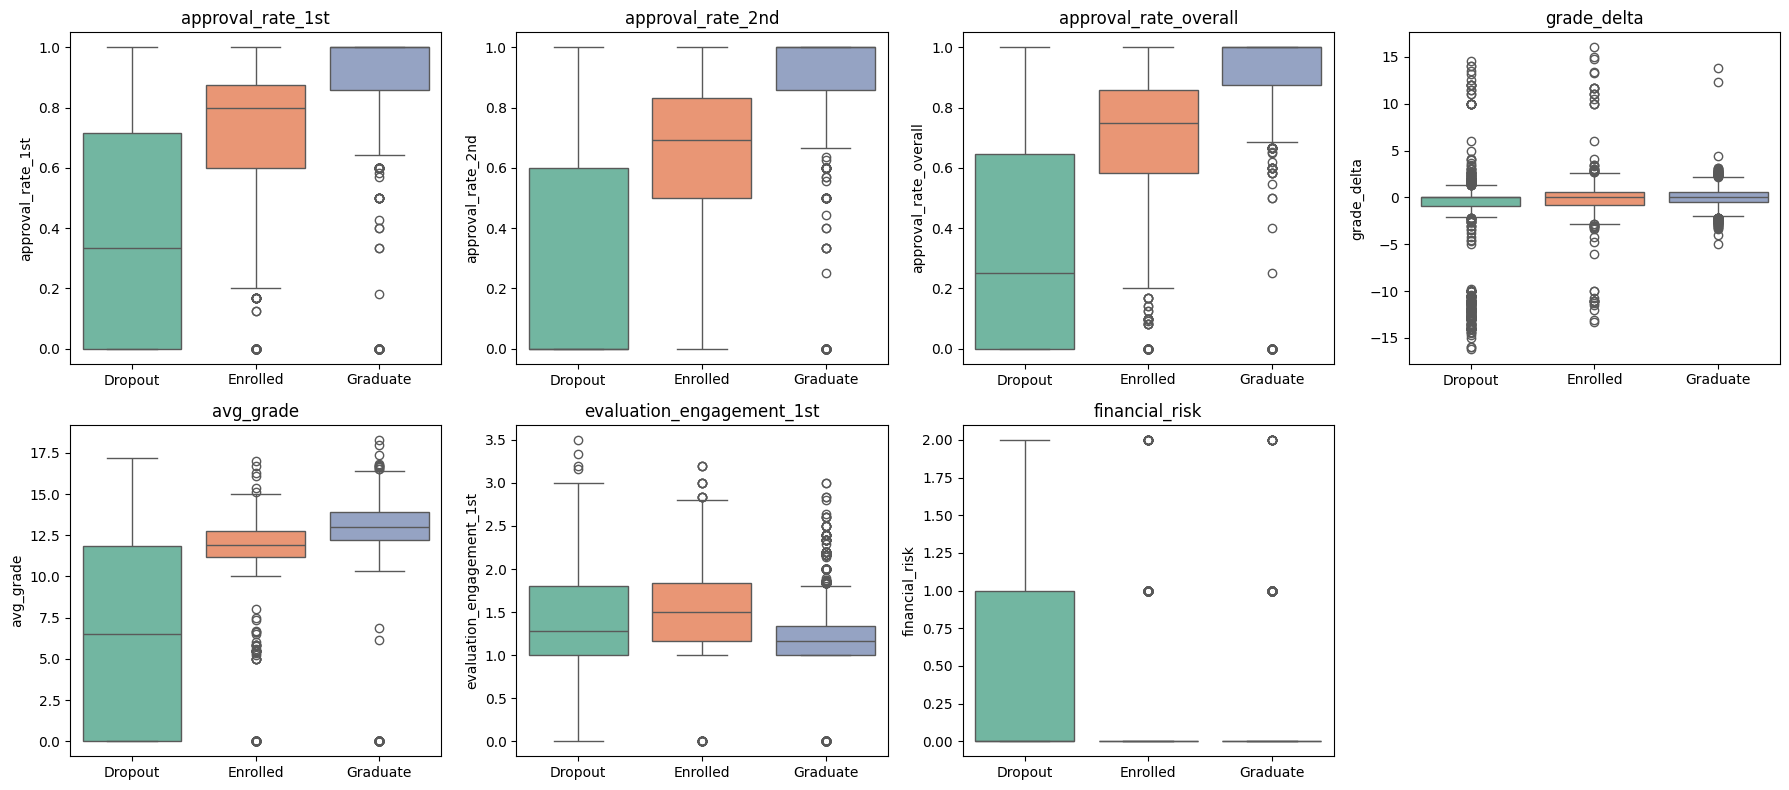

In [4]:
# Engineered-feature separation by class — quick visual sanity check
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
df_viz = engineered.copy()
df_viz['Target'] = df['Target']

for ax, col in zip(axes.flat, engineered.columns):
    sns.boxplot(data=df_viz, x='Target', y=col, ax=ax,
                order=LABEL_NAMES, palette='Set2')
    ax.set_title(col)
    ax.set_xlabel('')

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/engineered_features_by_class.png', dpi=150)
plt.show()

_TODO (analysis):_ Note which engineered features show the cleanest Dropout/Graduate separation and whether Enrolled lies between the two or overlaps one class — this foreshadows why Enrolled remains the hardest class.

## 3. Train/Test Split

Same 70/30 stratified split and seed as Phase 4 — keeps numbers directly comparable.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape}\nTest:  {X_test.shape}')

Train: (3096, 245)
Test:  (1328, 245)


## 4. Model Comparison via 5-Fold Stratified CV

Three model classes, each in a `Pipeline(StandardScaler + model)`:

- **Random Forest** — ensemble of decision trees; handles non-linear interactions, gives free feature importance.
- **Gradient Boosting** — strong tabular baseline; sequentially corrects residual errors.
- **SVM (RBF kernel)** — non-linear margin-based classifier; scaling is critical.

All use `class_weight='balanced'` where supported, to counter the 50/32/18 imbalance.

In [6]:
models = {
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=300, class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ]),
    'GradientBoosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=200, random_state=RANDOM_STATE,
        )),
    ]),
    'SVM-RBF': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='rbf', C=1.0, probability=True,
            class_weight='balanced', random_state=RANDOM_STATE,
        )),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'accuracy':       'accuracy',
    'f1_macro':       'f1_macro',
    'f1_weighted':    'f1_weighted',
    'roc_auc_ovr':    'roc_auc_ovr',
}

cv_rows = []
for name, pipe in models.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        'Model':          name,
        'Accuracy':       scores['test_accuracy'].mean(),
        'Accuracy_std':   scores['test_accuracy'].std(),
        'Macro-F1':       scores['test_f1_macro'].mean(),
        'Macro-F1_std':   scores['test_f1_macro'].std(),
        'Weighted-F1':    scores['test_f1_weighted'].mean(),
        'Macro AUC':      scores['test_roc_auc_ovr'].mean(),
        'Fit time (s)':   scores['fit_time'].mean(),
    })

cv_df = pd.DataFrame(cv_rows).sort_values('Macro-F1', ascending=False).reset_index(drop=True)
cv_df.round(4)

,Model,Accuracy,Accuracy_std,Macro-F1,Macro-F1_std,Weighted-F1,Macro AUC,Fit time (s)
0,GradientBoosting,0.7775,0.0250,0.7023,0.0253,0.7669,0.8910,3.1438
1,RandomForest,0.7778,0.0199,0.6983,0.0229,0.7637,0.8888,0.2939
2,SVM-RBF,0.7222,0.0142,0.6748,0.0172,0.7273,0.8651,1.3198


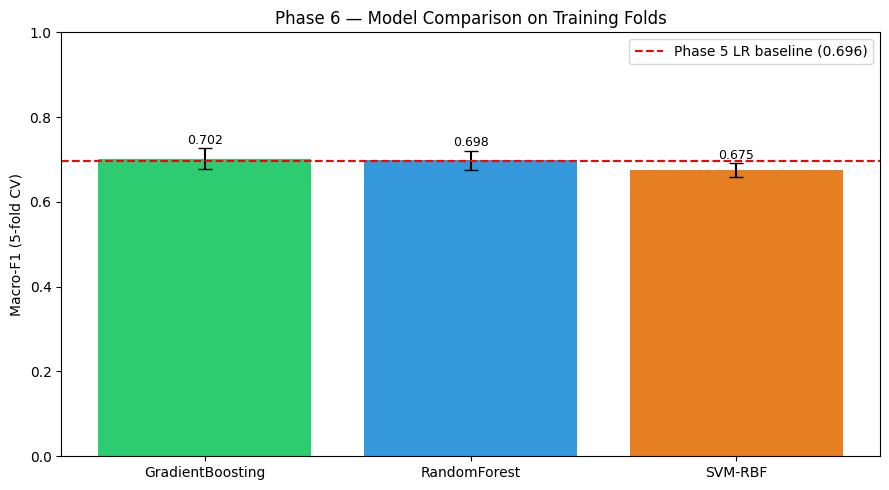

In [7]:
# Bar chart: CV macro-F1 (with std) for each model vs. the Phase 5 LR baseline
PHASE5_LR_BASELINE = {'Accuracy': 0.7643, 'Macro-F1': 0.6964, 'Macro AUC': 0.8620}

fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(cv_df))
ax.bar(x_pos, cv_df['Macro-F1'], yerr=cv_df['Macro-F1_std'],
       capsize=5, color=['#2ecc71', '#3498db', '#e67e22'])
ax.axhline(PHASE5_LR_BASELINE['Macro-F1'], ls='--', color='red',
           label=f"Phase 5 LR baseline ({PHASE5_LR_BASELINE['Macro-F1']:.3f})")
ax.set_xticks(x_pos)
ax.set_xticklabels(cv_df['Model'])
ax.set_ylabel('Macro-F1 (5-fold CV)')
ax.set_title('Phase 6 — Model Comparison on Training Folds')
ax.set_ylim(0, 1.0)
for i, row in cv_df.iterrows():
    ax.text(i, row['Macro-F1'] + row['Macro-F1_std'] + 0.01,
            f"{row['Macro-F1']:.3f}", ha='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/phase6_cv_comparison.png', dpi=150)
plt.show()

## 5. Holdout Evaluation of the Best Model

Refit each pipeline on the full training set and evaluate on the untouched test set. This gives the headline numbers to put in the report.

In [8]:
holdout_rows = []
fitted = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)
    holdout_rows.append({
        'Model':       name,
        'Accuracy':    accuracy_score(y_test, y_pred),
        'Macro-F1':    f1_score(y_test, y_pred, average='macro'),
        'Weighted-F1': f1_score(y_test, y_pred, average='weighted'),
        'Macro AUC':   roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'),
    })

holdout_df = pd.DataFrame(holdout_rows).sort_values('Macro-F1', ascending=False).reset_index(drop=True)
holdout_df.round(4)

,Model,Accuracy,Macro-F1,Weighted-F1,Macro AUC
0,GradientBoosting,0.7779,0.7120,0.7709,0.8920
1,RandomForest,0.7809,0.6988,0.7652,0.8897
2,SVM-RBF,0.7191,0.6785,0.7273,0.8695


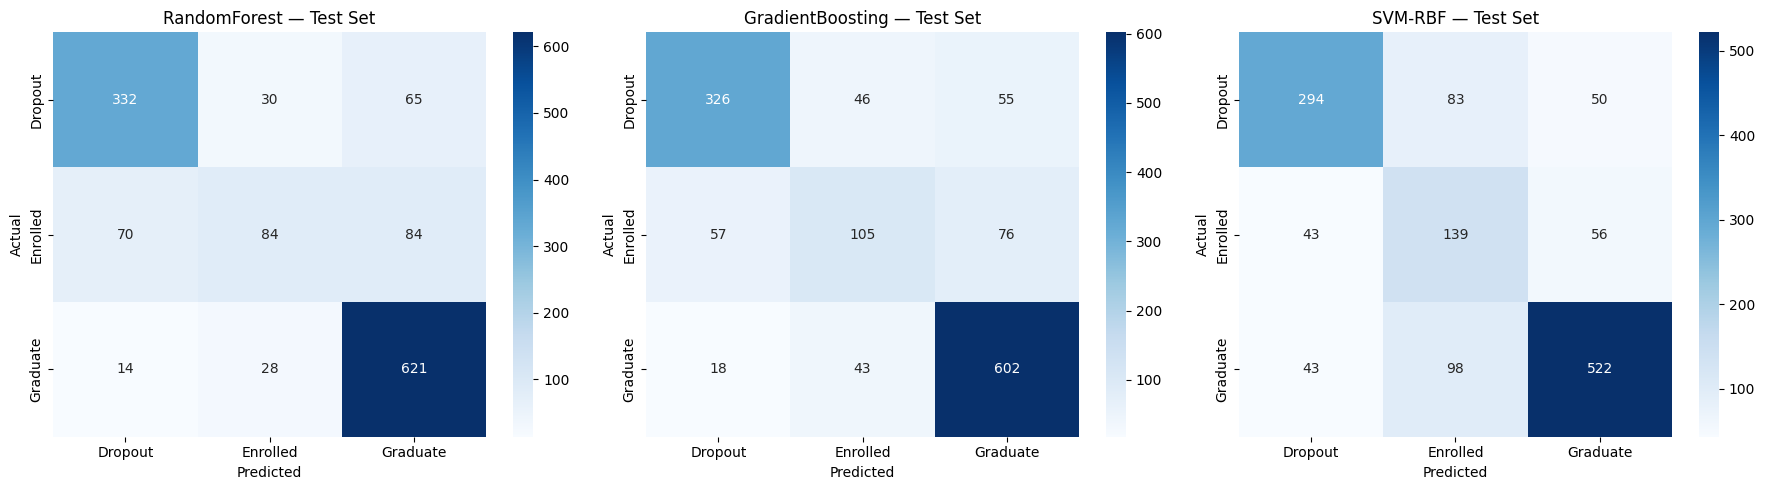

In [9]:
# Per-class confusion matrices on the holdout test set
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, pipe) in zip(axes, fitted.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{name} — Test Set')
plt.tight_layout()
plt.savefig('../outputs/phase6_confusion_matrices.png', dpi=150)
plt.show()

In [10]:
# Per-class classification reports — focus on Enrolled
for name, pipe in fitted.items():
    y_pred = pipe.predict(X_test)
    print(f'\n=== {name} — Test Set ===')
    print(classification_report(y_test, y_pred, target_names=LABEL_NAMES, digits=3))


=== RandomForest — Test Set ===
              precision    recall  f1-score   support

     Dropout      0.798     0.778     0.788       427
    Enrolled      0.592     0.353     0.442       238
    Graduate      0.806     0.937     0.867       663

    accuracy                          0.781      1328
   macro avg      0.732     0.689     0.699      1328
weighted avg      0.765     0.781     0.765      1328


=== GradientBoosting — Test Set ===
              precision    recall  f1-score   support

     Dropout      0.813     0.763     0.787       427
    Enrolled      0.541     0.441     0.486       238
    Graduate      0.821     0.908     0.862       663

    accuracy                          0.778      1328
   macro avg      0.725     0.704     0.712      1328
weighted avg      0.768     0.778     0.771      1328


=== SVM-RBF — Test Set ===
              precision    recall  f1-score   support

     Dropout      0.774     0.689     0.729       427
    Enrolled      0.434     0.5

## 6. Feature Importance (Random Forest)

Did the engineered features earn their keep? The RF `feature_importances_` gives an impurity-based ranking; values don't sum to meaningful probabilities but the ordering is informative.

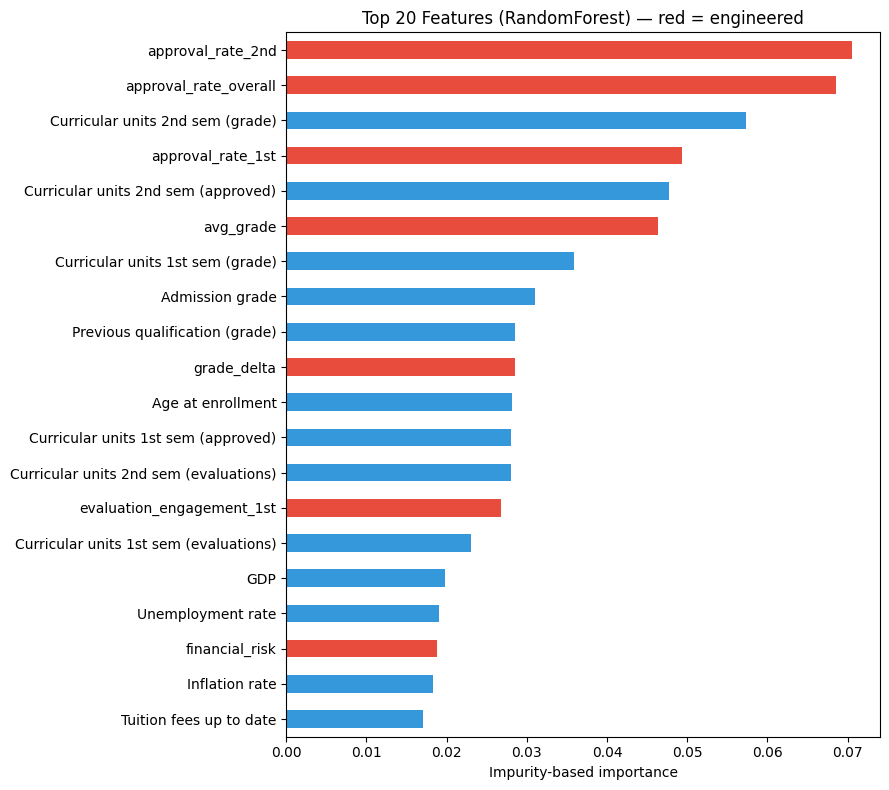


Engineered-feature ranks (1 = most important):
approval_rate_2nd             1
approval_rate_overall         2
approval_rate_1st             4
avg_grade                     6
grade_delta                  10
evaluation_engagement_1st    14
financial_risk               18
dtype: int64


In [11]:
rf = fitted['RandomForest'].named_steps['clf']
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top20 = importances.sort_values(ascending=True).tail(20)

engineered_cols = set(engineered.columns)
colors = ['#e74c3c' if c in engineered_cols else '#3498db' for c in top20.index]

fig, ax = plt.subplots(figsize=(9, 8))
top20.plot.barh(ax=ax, color=colors)
ax.set_xlabel('Impurity-based importance')
ax.set_title('Top 20 Features (RandomForest) — red = engineered')
plt.tight_layout()
plt.savefig('../outputs/phase6_feature_importance.png', dpi=150)
plt.show()

ranks_of_engineered = importances.rank(ascending=False).loc[list(engineered_cols)].sort_values()
print('\nEngineered-feature ranks (1 = most important):')
print(ranks_of_engineered.astype(int))

## 7. Discussion

_TODO: Fill in once you run the cells above. Suggested angles:_

- **Headline gain.** Compare the best model's holdout macro-F1 and macro AUC against the Phase 5 LR baseline (0.696 / 0.862). State the absolute and relative improvement.
- **Which model wins, and why.** Gradient Boosting usually edges RF on tabular data; SVM-RBF tends to shine when interactions are smooth. Tie the ranking back to the dataset's structure (categorical one-hot + continuous mix).
- **Enrolled class.** Did balanced class weighting + the new features lift Enrolled F1 above the ~0.48 baseline? If not, hypothesize why (e.g., Enrolled lies *between* Dropout and Graduate in feature space — see the t-SNE plot from Phase 2).
- **Engineered-feature value.** How many engineered features land in the top 20? Which ones are genuinely novel signal vs. correlated restatements of `Curricular units (approved)`?
- **Cost.** Note fit-time trade-offs from the CV table — SVM on 3k samples is ~seconds, RF/GBM are cheaper. Relevant if the use case is early-warning screening at scale.
- **Limitations.** Impurity importance biases toward high-cardinality features; a permutation-importance follow-up would be more trustworthy.

## 8. Summary and Links to the Report

_TODO: Fill in after analysis:_

- Best model: **<name>** — holdout accuracy **<x>**, macro-F1 **<y>**, macro AUC **<z>**.
- Baseline lift (vs. Phase 5 LR): **+<Δ>** macro-F1.
- Top engineered feature: **<name>** (rank **<r>**).
- Artifacts saved:
  - `outputs/engineered_features_by_class.png`
  - `outputs/phase6_cv_comparison.png`
  - `outputs/phase6_confusion_matrices.png`
  - `outputs/phase6_feature_importance.png`